In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import yfinance as yf

In [3]:
start_date = '2010-01-02'
end_date = '2025-12-31'
dat = yf.download('JPM', start = start_date, end = end_date, interval = '1d')

[*********************100%***********************]  1 of 1 completed


In [4]:
dat

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
Date,,,,,
2010-01-04,28.279192,28.371588,27.500442,27.579638,35460500
2010-01-05,28.826979,28.932572,28.233015,28.239616,41208300
2010-01-06,28.985359,29.097553,28.582787,28.675181,27729000
2010-01-07,29.559526,29.777311,28.780776,28.899568,44864700
2010-01-08,29.486927,29.500126,29.090953,29.282339,33110100
...,...,...,...,...,...
2025-12-23,322.814331,324.646652,320.001483,320.516501,6668300
2025-12-24,326.023376,326.835515,322.388446,323.121362,4289300


In [5]:
dat['p'] = dat['Close'].diff().dropna()
dat['r'] = dat['Close'] / dat['Close'].shift(1)
dat = dat.dropna()

In [6]:
df_train = dat[:'2021-12-31']
df_valid = dat['2022-01-01':'2023-12-31']
df_test = dat['2024-01-01':]
dat_r = dat['r']
dat_p = dat['p']

In [7]:
train_r = df_train['r']
valid_r = df_valid['r']
test_r = df_test['r']
train_p = df_train['p']
valid_p = df_valid['p']
test_p = df_test['p']

Model 1 - ARMA

In [8]:
from statsmodels.tsa.arima.model import ARIMA

In [9]:
best_rmse = np.inf
best_order = (0,0)
for p in range(0,6):
    for q in range(0,6):
        history = list(train_p)
        model = ARIMA(history, order=(p,0,q), trend='c').fit()
        preds = []
        for i in range(len(valid_p)):
            pred = model.forecast(steps=1)[0]
            preds.append(pred)
            model = model.append([valid_p.iloc[i]], refit=False)
        rmse = np.sqrt(np.mean((valid_p.values - np.array(preds))**2))
        if rmse < best_rmse:
            best_rmse = rmse
            best_order = (p, q)

C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Leno

In [10]:
best_order

(0, 0)

In [11]:
best_rmse

np.float64(1.954115307239622)

In [12]:
model = ARIMA(train_p, order=(0,0,0), trend='c').fit()
print(model.summary())

C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      p   No. Observations:                 3020
Model:                          ARIMA   Log Likelihood               -4820.465
Date:                Sun, 26 Apr 2026   AIC                           9644.929
Time:                        00:50:59   BIC                           9656.955
Sample:                             0   HQIC                          9649.254
                               - 3020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0374      0.022      1.721      0.085      -0.005       0.080
sigma2         1.4254      0.011    135.412      0.000       1.405       1.446
Ljung-Box (L1) (Q):                  34.44   Jarque-

In [13]:
price_change = model.forecast(steps=1).iloc[0]
price_change

C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Lenovo\.julia\conda\3\x86_64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


np.float64(0.03738744023060839)

In [14]:
p_current = dat['Close'].iloc[-1]
p_forecast = price_change + p_current
p_forecast

Ticker
JPM    320.365726
Name: 2025-12-30 00:00:00, dtype: float64

In [15]:
percentage_change = price_change/p_current * 100
percentage_change

Ticker
JPM    0.011672
Name: 2025-12-30 00:00:00, dtype: float64

For ARMA model, we predict the stock price next day is 320.37，RMSE = 1.9541, best order = (0, 0)

Model 2 - FNN

In [16]:
!pip install torch

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

In [18]:
def create_dataset(series, lookback):
    """
     
    Parameters:
        dataset: an array of time series observations with first dimension as time steps
        lookback: size of time window for predicting one time step ahead. Example: if the current time is t, we predict for t+1
        using observations from t, t-1, ..., t-lookback+1. 
    """
    X, Y = [], []
    for i in range(len(series) - lookback):
        X.append(series[i : i + lookback])    
        Y.append(series[i + lookback])        
    X = np.array(X).reshape(-1, lookback)
    Y = np.array(Y).reshape(-1, 1)           
    return torch.tensor(X).float(), torch.tensor(Y).float()

In [19]:
class PriceFNN(nn.Module):
    def __init__(self, lookback, hidden_size=50, num_layers=2):
        super().__init__()
        layers = []
        in_size = lookback
        for _ in range(num_layers):
            layers.append(nn.Linear(in_size, hidden_size))
            nn.init.kaiming_uniform_(layers[-1].weight, nonlinearity='relu')
            layers.append(nn.ReLU())
            in_size = hidden_size
        layers.append(nn.Linear(hidden_size, 1))      
        nn.init.xavier_uniform_(layers[-1].weight)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x) 

In [20]:
def checkpoint(model, optimizer, filename):
    torch.save({'model': model.state_dict(),
                'optimizer': optimizer.state_dict()}, filename)

def resume(model, optimizer, filename):
    ckpt = torch.load(filename)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])

In [21]:
def train_fnn(model, optimizer, loss_fn, dataloader, Xvalid, Yvalid,
              max_epochs=500, early_stop_thresh=100,
              scheduler=None, verbose=1, filename='best_fnn.pt'):
    
    rmse_train_list, rmse_valid_list = [], []
    best_rmse = np.inf
    best_epoch = -1

    for epoch in range(max_epochs):
        model.train()
        for x, y in dataloader:
            optimizer.zero_grad()
            ypred = model(x)
            loss = loss_fn(ypred, y)
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step(metrics=loss)

        rmse_train = np.sqrt(loss.detach().numpy())
        rmse_train_list.append(rmse_train)

        model.eval()
        with torch.no_grad():
            ypred_valid = model(Xvalid)
            loss_valid = loss_fn(ypred_valid, Yvalid)
        rmse_valid = np.sqrt(loss_valid.detach().numpy())
        rmse_valid_list.append(rmse_valid)

        if verbose:
            print(f'Epoch {epoch}, RMSE_train {rmse_train:.4f}, RMSE_valid {rmse_valid:.4f}')

        if rmse_valid < best_rmse:
            best_rmse = rmse_valid
            best_epoch = epoch
            checkpoint(model, optimizer, filename)
        elif epoch - best_epoch > early_stop_thresh:
            print(f'Early stopped at epoch {epoch}')
            break

    print(f'Training finished. Best RMSE_valid {best_rmse:.4f}, best epoch {best_epoch}')
    return rmse_train_list, rmse_valid_list, best_rmse, best_epoch

In [22]:
lookback_list  = [3, 5, 10]
hidden_sizes   = [50, 100]
num_layers_list = [1, 2]

best_hyperparams = {}
best_rmse_all = np.inf
loss_fn = nn.MSELoss()

for lookback in lookback_list:

    valid_p_ext = pd.concat([train_p.iloc[-lookback:], valid_p])

    Xtrain, Ytrain = create_dataset(train_p.values.squeeze(), lookback)
    Xvalid,  Yvalid  = create_dataset(valid_p_ext.values.squeeze(), lookback)

    trainset    = torch.utils.data.TensorDataset(Xtrain, Ytrain)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=len(Xtrain))

    for hidden_size in hidden_sizes:
        for num_layers in num_layers_list:
            model     = PriceFNN(lookback, hidden_size, num_layers)
            optimizer = optim.Adam(model.parameters(), lr=0.01)

            print(f'Training lookback={lookback}, hidden={hidden_size}, layers={num_layers}')
            _, _, rmse_valid, _ = train_fnn(
                model, optimizer, loss_fn, trainloader,
                Xvalid, Yvalid,
                max_epochs=500, early_stop_thresh=100,
                verbose=0, filename='best_fnn_tune.pt'
            )

            if rmse_valid < best_rmse_all:
                best_rmse_all = rmse_valid
                best_hyperparams = {'lookback': lookback,
                                    'hidden_size': hidden_size,
                                    'num_layers': num_layers}
                checkpoint(model, optimizer, 'best_fnn_hyperparams.pt')
                print(f'  Current best: {best_hyperparams}')

print('Best hyperparams:', best_hyperparams)

Training lookback=3, hidden=50, layers=1
Early stopped at epoch 125
Training finished. Best RMSE_valid 1.9593, best epoch 24
  Current best: {'lookback': 3, 'hidden_size': 50, 'num_layers': 1}
Training lookback=3, hidden=50, layers=2
Early stopped at epoch 144
Training finished. Best RMSE_valid 1.9818, best epoch 43
Training lookback=3, hidden=100, layers=1
Early stopped at epoch 157
Training finished. Best RMSE_valid 1.9936, best epoch 56
Training lookback=3, hidden=100, layers=2
Early stopped at epoch 137
Training finished. Best RMSE_valid 1.9856, best epoch 36
Training lookback=5, hidden=50, layers=1
Early stopped at epoch 127
Training finished. Best RMSE_valid 2.0096, best epoch 26
Training lookback=5, hidden=50, layers=2
Early stopped at epoch 133
Training finished. Best RMSE_valid 2.0025, best epoch 32
Training lookback=5, hidden=100, layers=1
Early stopped at epoch 183
Training finished. Best RMSE_valid 2.0600, best epoch 82
Training lookback=5, hidden=100, layers=2
Early stoppe

We choose N = 3

In [23]:
lb   = best_hyperparams['lookback']
test_p_ext = pd.concat([valid_p.iloc[-lb:], test_p])
Xtest, Ytest = create_dataset(test_p_ext.values.squeeze(), lb)

model_best = PriceFNN(lb, best_hyperparams['hidden_size'],
                          best_hyperparams['num_layers'])
optimizer_best = optim.Adam(model_best.parameters(), lr=0.01)
resume(model_best, optimizer_best, 'best_fnn_hyperparams.pt')

model_best.eval()
with torch.no_grad():
    Ypred_test = model_best(Xtest)

rmse_pc = np.sqrt(loss_fn(Ypred_test, Ytest).numpy())

In [24]:
p_current = dat['Close'].loc[test_p_ext.index[lb-1 : -1]]   
p_next    = dat['Close'].loc[test_p_ext.index[lb:]]          
p_forecast = p_current.values.squeeze() + Ypred_test.numpy().flatten()
p_forecast

array([161.1188135 , 163.15462478, 162.5281141 , 163.10561693,
       164.33903135, 163.91795965, 162.93594837, 162.87357979,
       162.38066567, 161.18391983, 160.27171156, 159.54157749,
       159.57882722, 162.41183503, 162.3193673 , 160.91801205,
       162.46207802, 164.97051387, 164.22956581, 164.31452531,
       167.9877453 , 166.43773866, 165.45489438, 166.37762858,
       166.52872138, 166.92374625, 167.33020079, 166.58269216,
       166.85456455, 167.63347466, 166.03025822, 167.75463428,
       171.45509984, 170.78055848, 170.67170548, 172.57490808,
       174.57753499, 175.73203564, 174.75451589, 174.86758182,
       175.82837768, 177.43996288, 176.53747343, 177.82885335,
       179.79904284, 181.01792353, 178.91524743, 179.29761417,
       179.3613968 , 181.09706156, 182.56456222, 179.04146777,
       180.91372561, 183.90927142, 185.01907313, 187.15364148,
       189.90405937, 187.0200519 , 186.26686704, 186.27508062,
       190.24362834, 191.23266011, 189.61171465, 189.55

In [25]:
with np.printoptions(suppress=True, precision=4):
    print(Ypred_test.numpy().flatten())

[-0.0149  0.1453  0.2293 -0.2703  0.1434 -0.0393  0.2749 -0.1306  0.0627
  0.0574  0.1555  0.2832  0.0059  0.0844  0.1825 -0.1513 -0.0465  0.1363
  0.0244 -0.3195 -0.0204  0.2501 -0.1323 -0.1627  0.2076  0.0308  0.1227
 -0.0243  0.0474  0.0829 -0.0621 -0.0247  0.0157  0.1418 -0.6342  0.1538
  0.0881  0.3658 -0.0113  0.016   0.0904  0.1007 -0.0679 -0.1013  0.0865
  0.3713 -0.1492 -0.1004 -0.1033  0.155   0.1547 -0.1183 -0.4668  0.2794
  0.3121  0.0257  0.1741 -0.3842  0.5782 -0.2809  0.0752  0.3208 -0.0038
  0.0182  0.0032  0.0555 -0.3238  0.3615 -0.1453  0.2882  0.1429  2.117
 -1.9772 -1.1986  0.0295 -0.1891 -0.1669  0.4804  0.1917  0.0759 -0.2079
  0.0492 -0.0503  0.0597 -0.0844 -0.1246  0.0196 -0.0619  0.2454 -0.0887
  0.2338 -0.2748 -0.0224  0.0442  0.1659 -0.1869  0.1121  0.8018 -1.6342
 -0.4897 -0.1017 -0.6285  0.519  -0.0577 -0.295   0.0607  0.1234  0.5919
  0.3683  0.1745 -0.229   0.1906  1.104   0.3341 -0.7891  0.1707 -0.1324
  0.0597  0.3543 -0.3349 -0.3487  0.2486 -0.0716 -0.

In [26]:
rmse = np.sqrt(np.mean((p_next.values.squeeze() - p_forecast)**2))
rmse

np.float64(3.6555903441506845)

In [27]:
results = pd.DataFrame({
    'True_price_change': Ytest.numpy().flatten(),
    'Pred_price_change': Ypred_test.numpy().flatten(),
    'True_price':        p_next.values.squeeze(),
    'Pred_price':        p_forecast
}, index=p_next.index)

In [28]:
results

,True_price_change,Pred_price_change,True_price,Pred_price
Date,,,,
2024-01-02,1.875610,-0.014899,163.009323,161.118813
2024-01-03,-0.710464,0.145302,162.298859,163.154625
2024-01-04,1.077057,0.229255,163.375916,162.528114
2024-01-05,0.819687,-0.270299,164.195602,163.105617
2024-01-08,-0.238297,0.143429,163.957306,164.339031
...,...,...,...,...
2025-12-23,2.812866,-0.302060,322.814331,319.699405
2025-12-24,3.209045,0.956694,326.023376,323.771025
2025-12-26,-1.247955,-0.167431,324.775421,325.855945


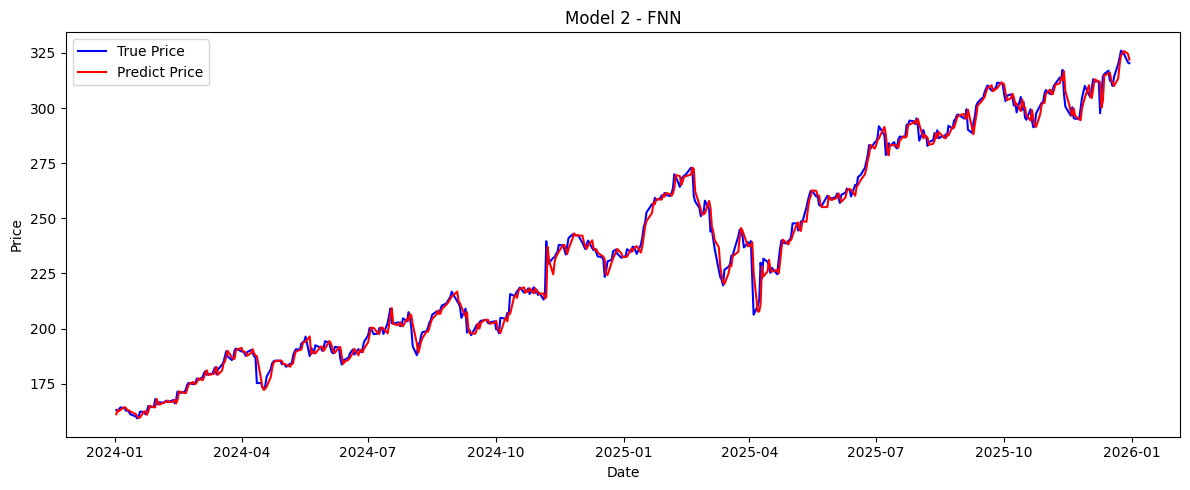

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(p_next.index, p_next.values.squeeze(), color = 'blue', label='True Price', linewidth=1.5)
plt.plot(p_next.index, p_forecast, color = 'red', label='Predict Price', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Model 2 - FNN')
plt.legend()
plt.tight_layout()
plt.show()

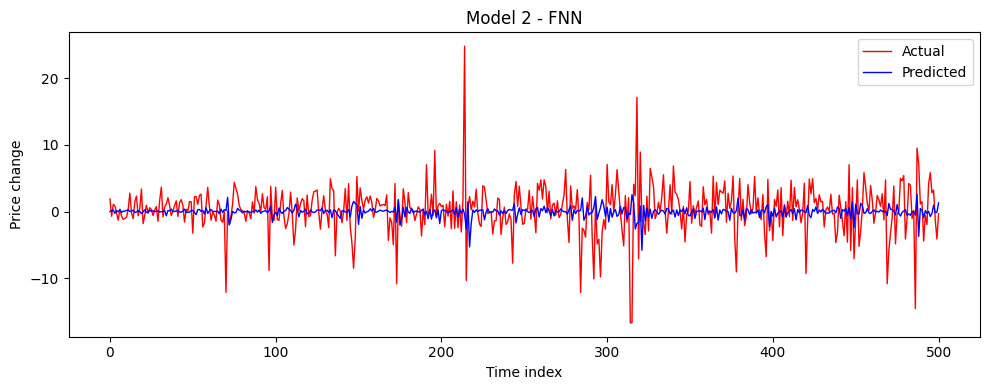

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))

price_change_true = Ytest.numpy().flatten()           
price_change_pred = Ypred_test.detach().numpy().flatten()  

ax.plot(price_change_true, color='red',  label='Actual',    linewidth=1)
ax.plot(price_change_pred, color='blue', label='Predicted',  linewidth=1)
ax.set_xlabel('Time index')
ax.set_ylabel('Price change')
ax.set_title('Model 2 - FNN')
ax.legend()
plt.tight_layout()
plt.show()

For FNN model, we predict the stock price next day is 321.61, RMSE = 3.6335, lookback=3, hidden=100, layers=1

Model 3 - LSTM

In [31]:
def create_dataset(dataset, lookback):
    """
    This function transforms a time series into a dataset with features and target for LSTM training
     
    Parameters:
        dataset: an array of time series observations with first dimension as time steps
        lookback: size of time window for predicting one time step ahead. Example: if the current time is t, we predict for t+1
        using observations from t, t-1, ..., t-lookback+1. 
    """
    X, Y = [], []
    for i in range(len(dataset)-lookback):
        feature = dataset[i: i+lookback]
        target = dataset[i+1: i+1+lookback]
        X.append(feature)
        Y.append(target)
    X = np.array(X).reshape(-1, lookback, 1)
    Y = np.array(Y).reshape(-1, lookback, 1)
    return torch.tensor(np.array(X)).float(), torch.tensor(np.array(Y)).float() 

In [32]:
class PriceLSTM(nn.Module):
    def __init__(self, hidden_size=10, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.out  = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x, _ = self.lstm(x)   
        x     = self.out(x)   
        return x

In [33]:
def checkpoint(model, optimizer, filename):
    torch.save({'model': model.state_dict(),
                'optimizer': optimizer.state_dict()}, filename)

def resume(model, optimizer, filename):
    ckpt = torch.load(filename)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])

In [34]:
def train_lstm(model, optimizer, loss_fn, dataloader, Xvalid, Yvalid,
               max_epochs=1000, early_stop_thresh=100,
               scheduler=None, verbose=1, filename='best_lstm.pt'):

    rmse_train_list = []
    best_rmse  = np.inf
    best_epoch = -1

    for epoch in range(max_epochs):
        model.train()
        for x, y in dataloader:
            optimizer.zero_grad()
            ypred = model(x)
            loss  = loss_fn(ypred[:, -1, :], y[:, -1, :])
            loss.backward()
            optimizer.step()
        if scheduler is not None:
            scheduler.step(metrics=loss)

        rmse_train = np.sqrt(loss.detach().numpy())
        rmse_train_list.append(rmse_train)

        model.eval()
        with torch.no_grad():
            ypred_valid = model(Xvalid)
            loss_valid  = loss_fn(ypred_valid[:, -1, :], Yvalid[:, -1, :])
        rmse_valid = np.sqrt(loss_valid.detach().numpy())

        if verbose:
            print(f'Epoch {epoch}, RMSE_train {rmse_train:.4f}, RMSE_valid {rmse_valid:.4f}')

        if rmse_valid < best_rmse:
            best_rmse  = rmse_valid
            best_epoch = epoch
            checkpoint(model, optimizer, filename)
        elif epoch - best_epoch > early_stop_thresh:
            print(f'Early stopped at epoch {epoch}')
            break

    print(f'Best RMSE_valid {best_rmse:.4f}, best epoch {best_epoch}')
    return rmse_train_list, best_rmse, best_epoch

In [46]:
lookback_list   = [3, 5, 10]
hidden_sizes    = [50, 100]
num_layers_list = [1, 2]

best_hyperparams = {}
best_rmse_all    = np.inf
loss_fn          = nn.MSELoss()

for lookback in lookback_list:
    p_valid_ext = pd.concat([train_p.iloc[-(lookback+1):], test_p])

    Xtrain, Ytrain = create_dataset(train_p.values.squeeze(), lookback)
    Xvalid,  Yvalid  = create_dataset(p_valid_ext.values.squeeze(), lookback)

    trainset    = torch.utils.data.TensorDataset(Xtrain, Ytrain)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=len(Xtrain))

    for hidden_size in hidden_sizes:
        for num_layers in num_layers_list:
            model     = PriceLSTM(hidden_size, num_layers)
            optimizer = optim.Adam(model.parameters(), lr=0.01)

            print(f'Training lookback={lookback}, hidden={hidden_size}, layers={num_layers}')
            _, rmse_valid, _ = train_lstm(
                model, optimizer, loss_fn, trainloader,
                Xvalid, Yvalid,
                max_epochs=1000, early_stop_thresh=100,
                verbose=0, filename='best_lstm_tune.pt'
            )

            if rmse_valid < best_rmse_all:
                best_rmse_all    = rmse_valid
                best_hyperparams = {'lookback': lookback,
                                    'hidden_size': hidden_size,
                                    'num_layers': num_layers}
                checkpoint(model, optimizer, 'best_lstm_hyperparams.pt')
                print(f'  Current best: {best_hyperparams}')

print('Best hyperparams:', best_hyperparams)

Training lookback=3, hidden=50, layers=1
Early stopped at epoch 101
Best RMSE_valid 3.5797, best epoch 0
  Current best: {'lookback': 3, 'hidden_size': 50, 'num_layers': 1}
Training lookback=3, hidden=50, layers=2
Early stopped at epoch 101
Best RMSE_valid 3.5780, best epoch 0
  Current best: {'lookback': 3, 'hidden_size': 50, 'num_layers': 2}
Training lookback=3, hidden=100, layers=1
Early stopped at epoch 101
Best RMSE_valid 3.5792, best epoch 0
Training lookback=3, hidden=100, layers=2
Early stopped at epoch 104
Best RMSE_valid 3.5793, best epoch 3
Training lookback=5, hidden=50, layers=1
Early stopped at epoch 103
Best RMSE_valid 3.5802, best epoch 2
Training lookback=5, hidden=50, layers=2
Early stopped at epoch 102
Best RMSE_valid 3.5755, best epoch 1
  Current best: {'lookback': 5, 'hidden_size': 50, 'num_layers': 2}
Training lookback=5, hidden=100, layers=1
Early stopped at epoch 101
Best RMSE_valid 3.5757, best epoch 0
Training lookback=5, hidden=100, layers=2
Early stopped at

In [47]:
lb = best_hyperparams['lookback']
p_test_ext = pd.concat([dat['Close'].loc[valid_p.iloc[-(lb+1):].index], dat['Close'].loc[test_p.index]])
Xtest, Ytest = create_dataset(p_test_ext.diff().dropna().values.reshape(-1, 1), lb)

model_best = PriceLSTM(best_hyperparams['hidden_size'],
                       best_hyperparams['num_layers'])
optimizer_best = optim.Adam(model_best.parameters(), lr=0.01)
resume(model_best, optimizer_best, 'best_lstm_hyperparams.pt')

model_best.eval()
with torch.no_grad():
    Ypred_test = model_best(Xtest)

rmse_pc = np.sqrt(loss_fn(Ypred_test[:, -1, :], Ytest[:, -1, :]).numpy())
print(f'Test RMSE: {rmse_pc:.4f}')

Test RMSE: 4.2191


In [52]:
p_test_prev = p_test_ext.iloc[lb:-1]   
p_test_next = p_test_ext.iloc[lb+1:]     
p_forecast = p_test_prev.values.squeeze() + Ypred_test[:, -1, :].numpy().flatten()
p_forecast

array([159.91700983, 161.59629416, 161.02396071, 163.82167155,
       164.10192615, 164.0730388 , 162.28513768, 162.55675259,
       162.36325725, 160.96392357, 159.77091911, 158.60111785,
       159.22201917, 162.68320811, 162.04181109, 160.2096746 ,
       162.45270332, 166.82617366, 162.79795063, 164.62910745,
       167.21733558, 163.46070862, 166.94808614, 166.49631312,
       165.51913679, 166.30989194, 165.47948384, 166.06087363,
       166.15915942, 168.0081394 , 166.13932122, 167.83604681,
       170.87065303, 170.95638606, 171.69866529, 172.3978018 ,
       174.263953  , 175.58687419, 174.0903337 , 175.8724556 ,
       175.8332046 , 177.02400076, 176.88301766, 176.89098561,
       180.29493356, 180.66185537, 179.2889916 , 179.3286821 ,
       179.41303181, 181.11562732, 181.95181027, 177.97800732,
       180.45271027, 184.57593048, 184.51572965, 186.78659961,
       189.57000446, 185.54928041, 187.66908872, 189.70763564,
       191.41157067, 192.81221676, 189.42796353, 189.50

In [49]:
rmse = np.sqrt(np.mean((p_test_next.values.squeeze() - p_forecast)**2))
rmse

np.float64(4.219096859685491)

In [56]:
results = pd.DataFrame({
    'True_price_change': Ytest[:, -1, :].numpy().flatten(),       
    'Pred_price_change': Ypred_test[:, -1, :].numpy().flatten(),  
    'True_price':        p_next.values.squeeze(),
    'Pred_price':        p_forecast
}, index=p_next.index)

In [57]:
results

,True_price_change,Pred_price_change,True_price,Pred_price
Date,,,,
2024-01-02,1.875610,-1.216703,163.009323,159.917010
2024-01-03,-0.710464,-1.413029,162.298859,161.596294
2024-01-04,1.077057,-1.274898,163.375916,161.023961
2024-01-05,0.819687,0.445756,164.195602,163.821672
2024-01-08,-0.238297,-0.093676,163.957306,164.101926
...,...,...,...,...
2025-12-23,2.812866,0.571126,322.814331,320.572590
2025-12-24,3.209045,0.407544,326.023376,323.221875
2025-12-26,-1.247955,0.112149,324.775421,326.135525


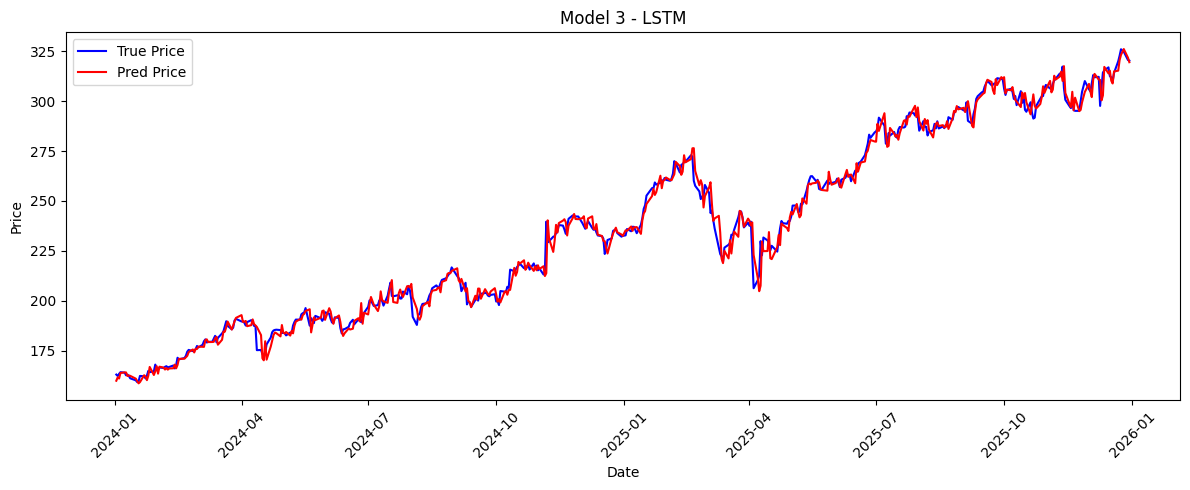

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(p_test_next.index, p_test_next.values.squeeze(),
         color='blue', label='True Price', linewidth=1.5)
plt.plot(p_test_next.index, p_forecast,
         color='red',  label='Pred Price', linewidth=1.5)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Model 3 - LSTM')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

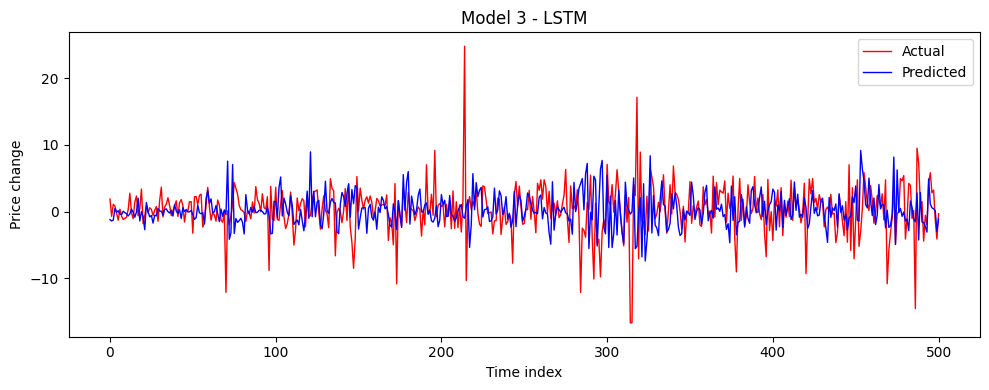

In [60]:
fig, ax = plt.subplots(figsize=(10, 4))

price_change_true = Ytest[:, -1, :].numpy().flatten()           
price_change_pred = Ypred_test.detach()[:, -1, :].numpy().flatten()  

ax.plot(price_change_true, color='red',  label='Actual', linewidth=1)
ax.plot(price_change_pred, color='blue', label='Predicted', linewidth=1)
ax.set_xlabel('Time index')
ax.set_ylabel('Price change')
ax.set_title('Model 3 - LSTM')
ax.legend()
plt.tight_layout()
plt.show()

For LSTM model, we predict the stock price next day is 319.55, RMSE = 4.219, lookback=10, hidden=50, layers=1

ARMA(0,0) reduces to a constant mean model, so daily JPM price changes are rarely predictable from historical data; FNN achieved the better test RMSE among the two neural models, but recent price history has limited predictive power; LSTM had a higher test RMSE than FNN, mostly because its complex architecture requires more training data to generalize.